In [1]:
import decode
import decode.utils
import decode.neuralfitter.train.live_engine
import scipy.ndimage as ndi
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tifffile
import tqdm

print(f"DECODE version: {decode.utils.bookkeeping.decode_state()}")

DECODE version: 0.10.2


In [2]:
device = 'cuda:0'  # or 'cpu'
device_ix = 1  # possibly change device index (only for cuda)
threads = 4  #  number of threads, useful for CPU heavy computation. Change if you know what you are doing.
worker = 4  # number of workers for data loading. Change only if you know what you are doing.

torch.set_num_threads(threads)  # set num threads

if device != 'cpu':
    if (not torch.cuda.is_available()) or (not decode.simulation.psf_kernel.CubicSplinePSF.cuda_is_available()):
        raise ValueError("You have selected a non CPU device, but CUDA is not available."
                         "Refer to CPU version or check your installation.")

In [3]:
# uncomment and exectue only if you have not executed the example download cell above
calib_file = 'z-stack-3dcal.mat'
#calib_file = 'old.mat' #safe and old calib

In [4]:
# copy default parameter files which are then changed as specified
decode.utils.param_io.copy_reference_param('')  # saved in current dir

In [5]:
param = decode.utils.param_io.load_params('param_gauss_seed.yaml')  # change path if you load custom file

param.Hardware.device = device
param.Hardware.device_ix = device_ix
param.Hardware.device_simulation = device
param.Hardware.torch_threads = threads
param.Hardware.num_worker_train = worker
param.InOut.calibration_file = calib_file
param.InOut.experiment_out = ''
param.HyperParameter.batch_size = 32
display(param.InOut.to_dict())

display(param.Camera.to_dict())

# param.Simulation.bg_uniform = [200.0, 400.0]           # background range to sample from. You can also specify a const. value as 'bg_uniform = 100'
# param.Simulation.emitter_av = 50                 # Average number of emitters per frame
# param.Simulation.emitter_extent[2] = [-5, 5]    # Volume in which emitters are sampled. x,y values should not be changed. z-range (in nm) should be adjusted according to the PSF
# param.Simulation.intensity_mu_sig = [2_00_000.0, int(2_00_000**0.5)]  # Average intensity and its standard deviation
# param.Simulation.lifetime_avg = 1.25                     # Average lifetime of each emitter in frames. A value between 1 and 2 works for most experiments

display(param.Simulation.to_dict())

{'calibration_file': 'z-stack-3dcal.mat',
 'experiment_out': '',
 'checkpoint_init': None,
 'model_init': None}

{'baseline': 100.0,
 'e_per_adu': 45.0,
 'em_gain': 300.0,
 'px_size': [60.0, 60.0],
 'read_sigma': 70,
 'spur_noise': 0.0,
 'convert2photons': True,
 'qe': 1.0}

{'bg_uniform': [90, 150],
 'emitter_av': 50,
 'emitter_extent': [[-0.5, 39.5], [-0.5, 39.5], [-0.5, 0.5]],
 'intensity_mu_sig': [10000.0, 3000.0],
 'lifetime_avg': 1.25,
 'density': None,
 'img_size': [40, 40],
 'intensity_th': None,
 'mode': 'acquisition',
 'photon_range': None,
 'psf_extent': [[-0.5, 39.5], [-0.5, 39.5], None],
 'roi_size': None,
 'roi_auto_center': False,
 'xy_unit': 'px'}

In [6]:
simulator, sim_test = decode.neuralfitter.train.live_engine.setup_random_simulation(param)
camera = decode.simulation.camera.Photon2Camera.parse(param)
param = decode.utils.param_io.autoset_scaling(param)

_, sim_frames, _ = simulator.sample()


In [17]:
from decode.generic import EmitterSet

def estim_snr(frame, plot=False):
    #assume centered emitter
    cut = ndi.median_filter(frame[20],1)
    bckg = frame[0:10,0:10]
    bstd = np.std(bckg.ravel())
    bmu = np.mean(bckg.ravel())
    peak = np.max(cut)
    snr = (peak-bmu)/(bstd)
    if plot:
        plt.plot((cut-bmu)/bstd)
        plt.show()
    return snr
    
#my frame of 1 emitter

intensities = np.logspace(0.5, 6, 201)
snrs = []
for inten in tqdm.tqdm(intensities):
    xyz = torch.tensor([[20,20,0]], dtype=torch.float32)
    photons = torch.tensor([inten])
    frame_ix = torch.tensor([0], dtype=torch.int32, device='cpu')
    emid = torch.tensor([0], dtype=torch.int32)
    emprob = torch.tensor([1])
    embckg = torch.tensor([150])
    emset = EmitterSet(xyz, photons, frame_ix, emid, emprob, embckg, xy_unit='px', px_size=60)
    simframe, bckg = simulator.forward(emset)
    n_simframe = simframe.detach().cpu().numpy()[0]
    snrs.append(estim_snr(n_simframe))


100%|█████████████████████████████████████████████████████████████████████████████████| 201/201 [00:13<00:00, 14.43it/s]


[0.00222307 1.47107874]


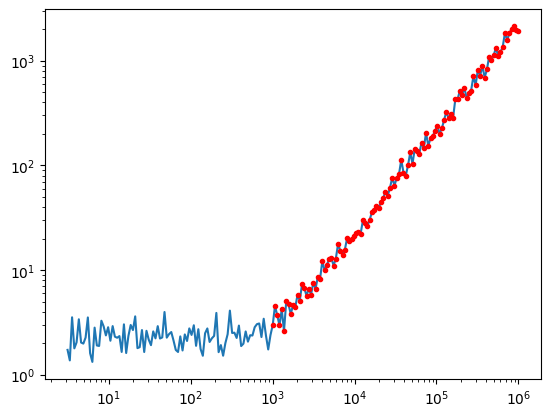

In [18]:
sel_for_fit = (intensities > 1e3).astype(bool)
snrs = np.array(snrs)
line_coef = np.polyfit(intensities, snrs, 1) 
print(line_coef)
plt.loglog(intensities, snrs, "-")
plt.loglog(intensities[sel_for_fit], snrs[sel_for_fit], "r.")
# plt.matshow(n_simframe)
# plt.colorbar()

Relation between SNR and nominal emitter intensity:

$SNR = 2.1\cdot 10^{-3} I + 15$

how to select intensity to obtaine desired SNR:

$(SNR-15)/2.1 \times 1000 = I$

In [19]:
my_snrs = np.array([   1.        ,    1.99526231,    3.98107171,    7.94328235,15.84893192,   31.6227766 ,   63.09573445,  125.89254118, 251.18864315,  501.18723363, 1000.        ])
my_snrs[4:-1]
selected_intensities = []
actual_snrs = []
for my_snr in my_snrs[4:-1]:
    isel = np.argmin((snrs - my_snr)**2)
    selected_intensities.append(intensities[isel])
    actual_snrs.append(snrs[isel])
    print(my_snr, isel, snrs[isel])

selected_intensities = np.array(selected_intensities).astype(int)
print(selected_intensities)

15.84893192 123 15.675861
31.6227766 134 30.080338
63.09573445 145 64.05842
125.89254118 156 129.34216
251.18864315 164 239.77634
501.18723363 178 490.6861
[  7629  15310  30725  61659 102329 248313]


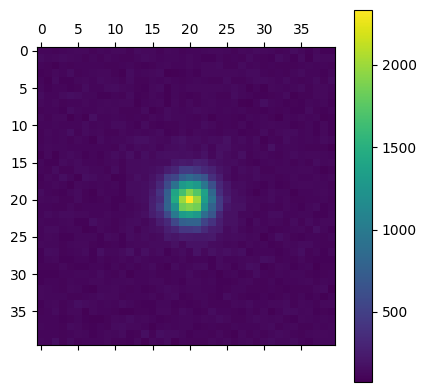

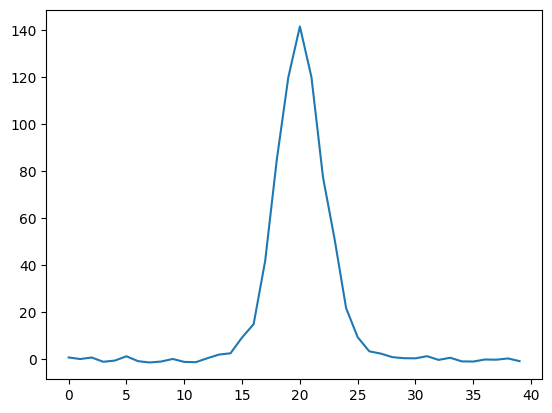

(141.48087, 61659)

In [20]:
#test at SNR 5
#snr_dest = 15.8
#intensity = (snr_dest - 5)*1e3/2 #works for low SNRs
intensity = selected_intensities[3]
xyz = torch.tensor([[20,20,0]], dtype=torch.float32)
photons = torch.tensor([intensity])
frame_ix = torch.tensor([0], dtype=torch.int32, device='cpu')
emid = torch.tensor([0], dtype=torch.int32)
emprob = torch.tensor([1])
embckg = torch.tensor([150])
emset = EmitterSet(xyz, photons, frame_ix, emid, emprob, embckg, xy_unit='px', px_size=60)
simframe, bckg = simulator.forward(emset)
n_simframe = simframe.detach().cpu().numpy()[0]
plt.matshow(n_simframe)
plt.colorbar()
plt.show()
estim_snr(n_simframe, plot=True), intensity


In [21]:
def set_params_to_snr(params, snr):
    if snr < 25:
        intensity = (snr - 5)*1e3/2 #works for low SNRs
    elif snr < 100:
        intensity = (snr - 10)*1e3/2 #works for high SNRs
    else:
        intensity = (snr - 30)*1e3/4 #works for high SNRs
            
    params.Simulation.bg_uniform = [100.0, 150.0] # background range to sample from. You can also specify a const. value as 'bg_uniform = 100'
    params.Simulation.emitter_av = 50 # Average number of emitters per frame
    params.Simulation.emitter_extent[2] = [-0.5, 0.5] # Volume in which emitters are sampled. x,y values should not be changed. z-range (in nm) should be adjusted according to the PSF
    params.Simulation.intensity_mu_sig = [int(intensity), int(intensity*0.1)]  # Average intensity and its standard deviation
    params.Simulation.lifetime_avg = 1.25  # Average lifetime of each emitter in frames. A value between 1 and 2 works for most experiments
    return params, intensity

def set_params_to_int(params, intensity):    
    params.Simulation.bg_uniform = [100.0, 150.0] # background range to sample from. You can also specify a const. value as 'bg_uniform = 100'
    params.Simulation.emitter_av = 50 # Average number of emitters per frame
    params.Simulation.emitter_extent[2] = [-0.5, 0.5] # Volume in which emitters are sampled. x,y values should not be changed. z-range (in nm) should be adjusted according to the PSF
    params.Simulation.intensity_mu_sig = [int(intensity), int(intensity*0.1)]  # Average intensity and its standard deviation
    params.Simulation.lifetime_avg = 1.25  # Average lifetime of each emitter in frames. A value between 1 and 2 works for most experiments
    return params, intensity



def estim_snr2(frame, plot=False):
    #assume centered emitter
    ints = np.max(frame, axis=1)
    imx = np.argmax(ints)
    imn = np.argmin(ints)
    print(imx)
    cut = frame[imx]
    bckg = frame[imn]
    bstd = np.std(bckg.ravel())
    bmu = np.mean(bckg.ravel())
    peak = np.max(cut)
    snr = (peak-bmu)/(bstd)
    if plot:
        plt.plot((cut-bmu)/bstd)
        plt.show()
    return snr

def test_snr(_param, plot=False):
    simulator, sim_test = decode.neuralfitter.train.live_engine.setup_random_simulation(_param)
    intensity, std = _param.Simulation.intensity_mu_sig
    print("debug:", intensity)
    xyz = torch.tensor([[20,20,0]], dtype=torch.float32)
    photons = torch.tensor([intensity])
    frame_ix = torch.tensor([0], dtype=torch.int32, device='cpu')
    emid = torch.tensor([0], dtype=torch.int32)
    emprob = torch.tensor([1])
    embckg = torch.tensor([150])
    emset = EmitterSet(xyz, photons, frame_ix, emid, emprob, embckg, xy_unit='px', px_size=60)
    simframe, bckg = simulator.forward(emset)
    n_simframe = simframe.detach().cpu().numpy()[0]
    actual_snr = estim_snr(n_simframe, plot)
    return actual_snr, n_simframe

debug: 7629


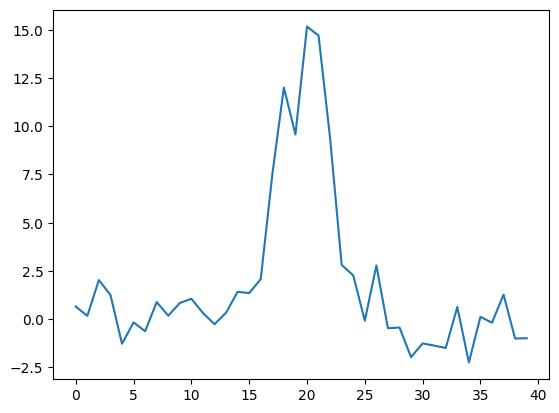

7629 [7629, 762]
7629 15.167833 notebook_training_new_snr_15.yaml
debug: 15310


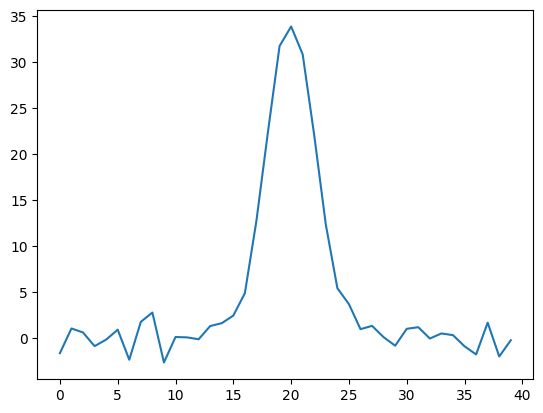

15310 [15310, 1531]
15310 33.887295 notebook_training_new_snr_33.yaml
debug: 30725


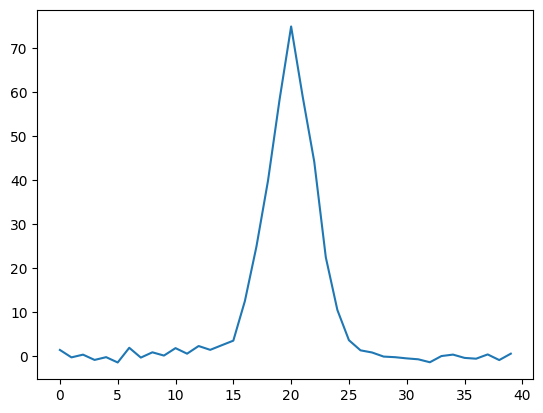

30725 [30725, 3072]
30725 74.88774 notebook_training_new_snr_74.yaml
debug: 61659


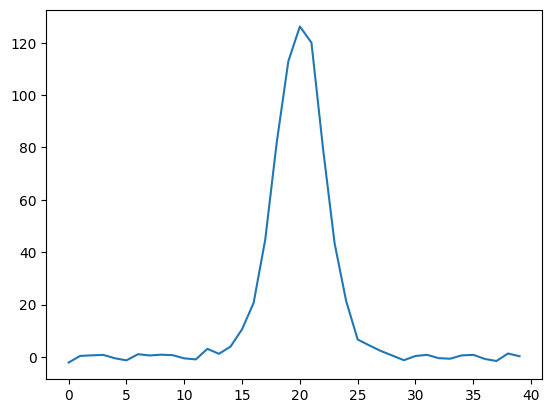

61659 [61659, 6165]
61659 126.205864 notebook_training_new_snr_126.yaml
debug: 102329


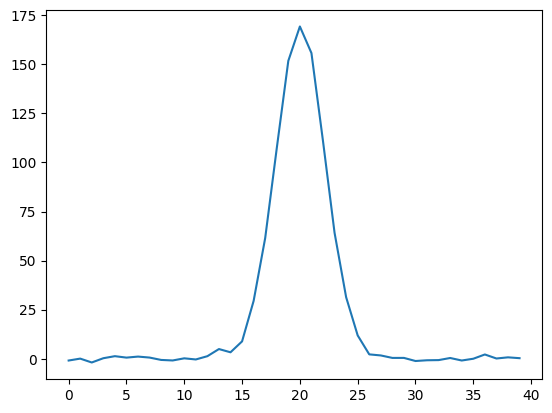

102329 [102329, 10232]
102329 169.29152 notebook_training_new_snr_169.yaml
debug: 248313


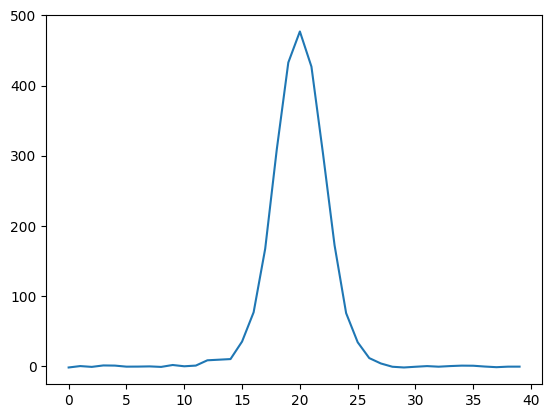

248313 [248313, 24831]
248313 477.11816 notebook_training_new_snr_477.yaml


In [24]:
#tested_snrs = [20, 50, 100, 500]

param.Scaling.phot_max = 9.5e5

switcher = False
for __int in selected_intensities:
    _params, _int = set_params_to_int(param, __int)
    actual_snr, test_img = test_snr(_params, plot=True)
    if switcher:
        _params.Hardware.device = 'cuda:1'
    else:
        _params.Hardware.device = 'cuda:0'
    switcher = not(switcher)
    np.save(f'test_img_{int(actual_snr):d}.npy', test_img)
    print(_int, param.Simulation.intensity_mu_sig)
    param_out_path = f'notebook_training_new_snr_{int(actual_snr):d}.yaml' # or an alternative path
    _params.InOut.experiment_out = f'run2_{int(actual_snr):d}'
    decode.utils.param_io.save_params(param_out_path, _params)
    print(__int, actual_snr, param_out_path)

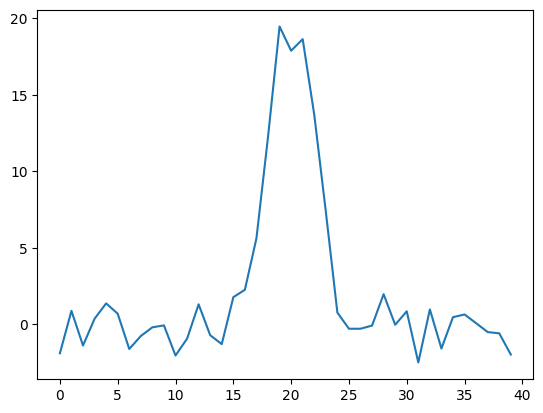

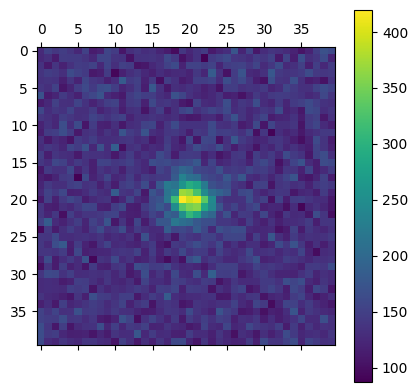

20 7500.0 19.45977


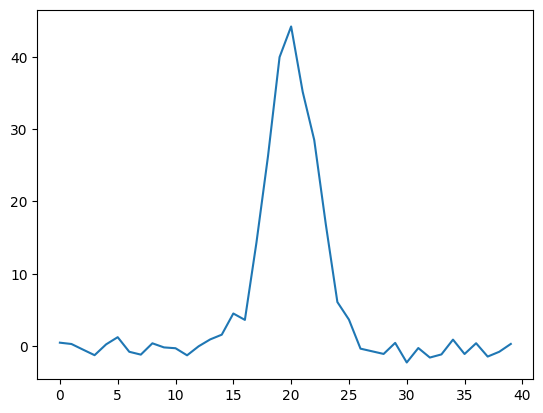

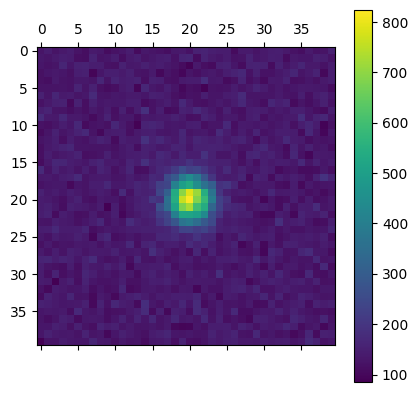

50 20000.0 44.17783


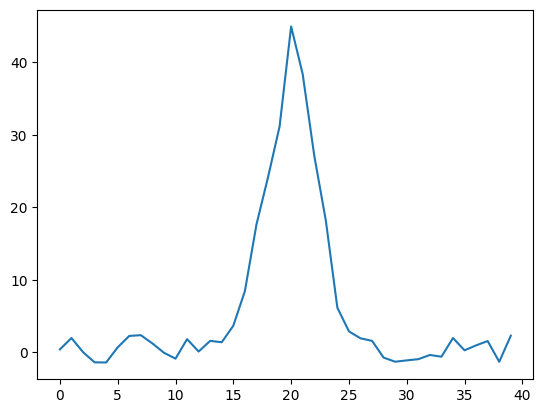

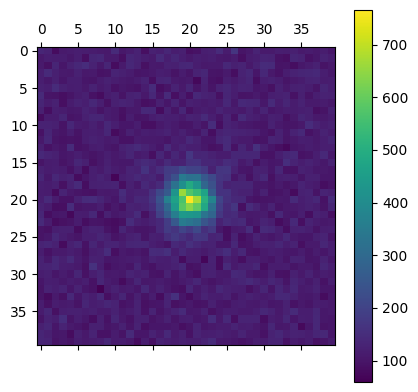

100 17500.0 44.923325


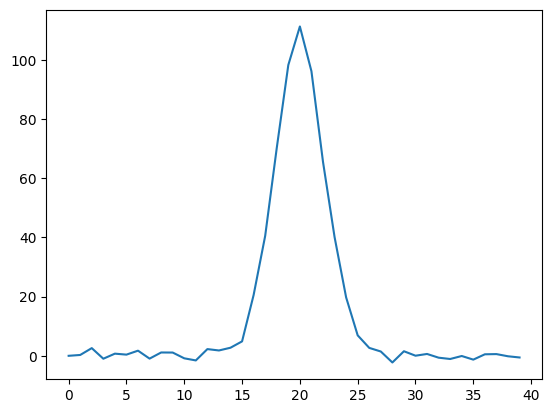

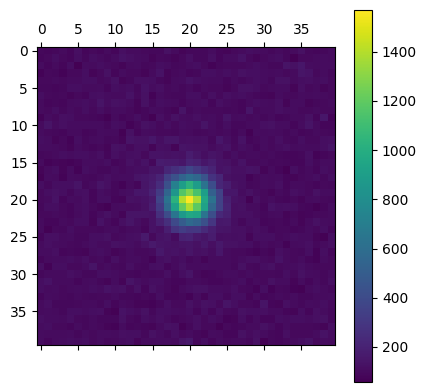

200 42500.0 111.32678


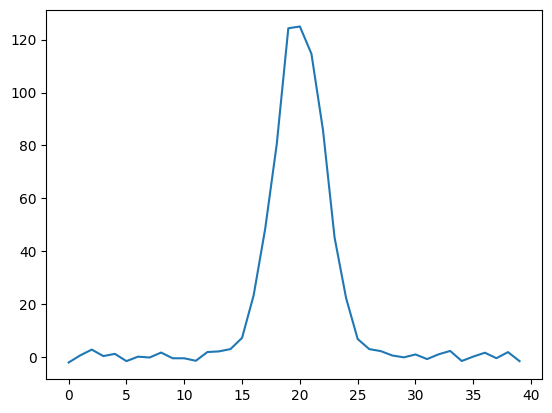

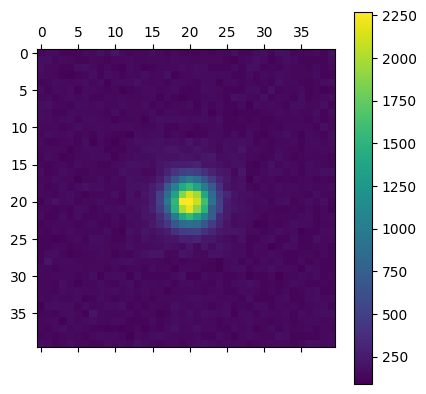

300 67500.0 124.981255


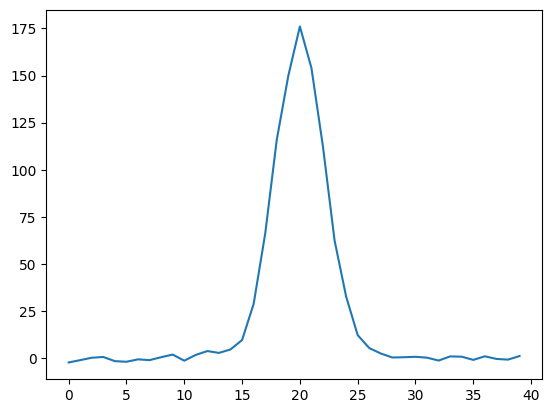

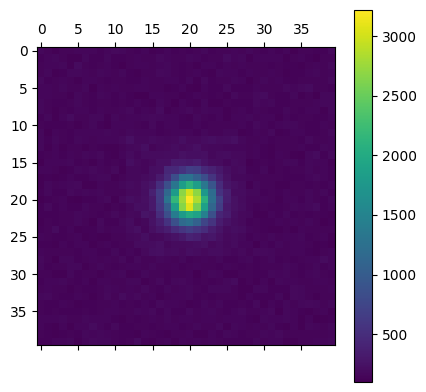

400 92500.0 176.0568


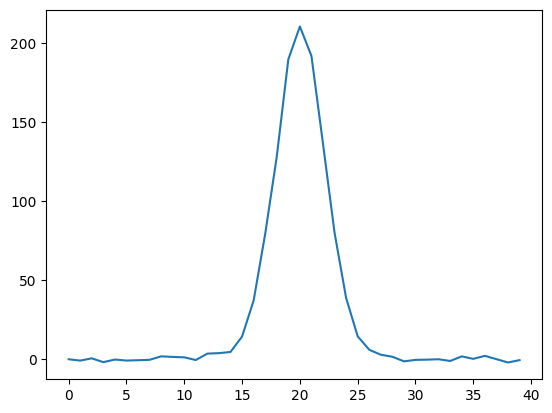

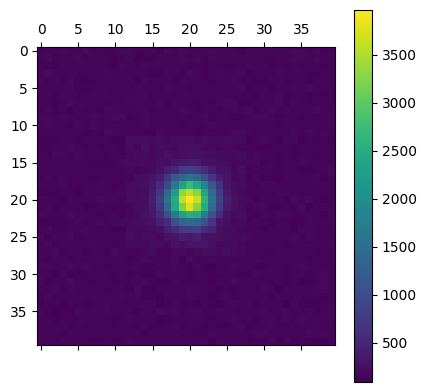

500 117500.0 210.46062


In [24]:
snr_map = dict()
for snr_dest in [20, 50, 100, 200, 300, 400, 500]:
    params, intensity = set_params_to_snr(param, snr_dest)    
    #intensity = (snr_dest - 5)*1e3/2 #works for low SNRs
    xyz = torch.tensor([[20,20,0]], dtype=torch.float32)
    photons = torch.tensor([intensity])
    frame_ix = torch.tensor([0], dtype=torch.int32, device='cpu')
    emid = torch.tensor([0], dtype=torch.int32)
    emprob = torch.tensor([1])
    embckg = torch.tensor([125])
    emset = EmitterSet(xyz, photons, frame_ix, emid, emprob, embckg, xy_unit='px', px_size=60)
    simframe, bckg = simulator.forward(emset)
    n_simframe = simframe.detach().cpu().numpy()[0]
    snr_est = estim_snr(n_simframe, plot=True)
    plt.matshow(n_simframe)
    plt.colorbar()
    plt.show()
    print(snr_dest, intensity, snr_est)
    snr_map[snr_dest] = (intensity, snr_est)
    

In [35]:
import os

snrs = [15, 33, 74, 126, 169, 477]
fndict = {}
for s in snrs:
    dname = f'run2_{s:d}'
    sdname = os.listdir(dname)[0]
    fname_model = os.path.join(dname, sdname, 'model_0.pt')
    fname_param = os.path.join(dname, sdname, 'param_run.yaml')
    fndict[s] = (fname_model, fname_param)

import json

with open('paths.json', 'w') as f:
    json.dump(fndict, f)
    print(json.dumps(fndict))

{"15": ["run2_15/2025-10-17_15-57-53_001.cluster.qolo/model_0.pt", "run2_15/2025-10-17_15-57-53_001.cluster.qolo/param_run.yaml"], "33": ["run2_33/2025-10-17_15-59-42_002.cluster.qolo/model_0.pt", "run2_33/2025-10-17_15-59-42_002.cluster.qolo/param_run.yaml"], "74": ["run2_74/2025-10-17_16-00-00_002.cluster.qolo/model_0.pt", "run2_74/2025-10-17_16-00-00_002.cluster.qolo/param_run.yaml"], "126": ["run2_126/2025-10-17_16-04-26_004.cluster.qolo/model_0.pt", "run2_126/2025-10-17_16-04-26_004.cluster.qolo/param_run.yaml"], "169": ["run2_169/2025-10-17_16-05-02_004.cluster.qolo/model_0.pt", "run2_169/2025-10-17_16-05-02_004.cluster.qolo/param_run.yaml"], "477": ["run2_477/2025-10-17_16-04-44_003.cluster.qolo/model_0.pt", "run2_477/2025-10-17_16-04-44_003.cluster.qolo/param_run.yaml"]}
